Epoch 0: D Loss: 1.5487, G Loss: -0.4169, G Grad Norm^2: 0.008870
Epoch 100: D Loss: 0.8701, G Loss: -0.4184, G Grad Norm^2: 0.070477
Epoch 200: D Loss: 0.5773, G Loss: -0.1914, G Grad Norm^2: 0.140837
Epoch 300: D Loss: 0.7333, G Loss: -0.2991, G Grad Norm^2: 3.689119
Epoch 400: D Loss: 0.6903, G Loss: -0.3021, G Grad Norm^2: 1.703829
Epoch 500: D Loss: 0.6964, G Loss: -0.2984, G Grad Norm^2: 0.998838
Epoch 600: D Loss: 0.6713, G Loss: -0.2910, G Grad Norm^2: 1.154474
Epoch 700: D Loss: 0.7062, G Loss: -0.3158, G Grad Norm^2: 0.853028
Epoch 800: D Loss: 0.7682, G Loss: -0.3152, G Grad Norm^2: 1.064413
Epoch 900: D Loss: 0.8001, G Loss: -0.3289, G Grad Norm^2: 0.191469
Epoch 1000: D Loss: 0.8197, G Loss: -0.3290, G Grad Norm^2: 0.467060
Epoch 1100: D Loss: 0.8168, G Loss: -0.3387, G Grad Norm^2: 0.107765
Epoch 1200: D Loss: 0.8189, G Loss: -0.3303, G Grad Norm^2: 0.632649
Epoch 1300: D Loss: 1.1426, G Loss: -0.5340, G Grad Norm^2: 24.579822
Epoch 1400: D Loss: 1.0116, G Loss: -0.5300, 

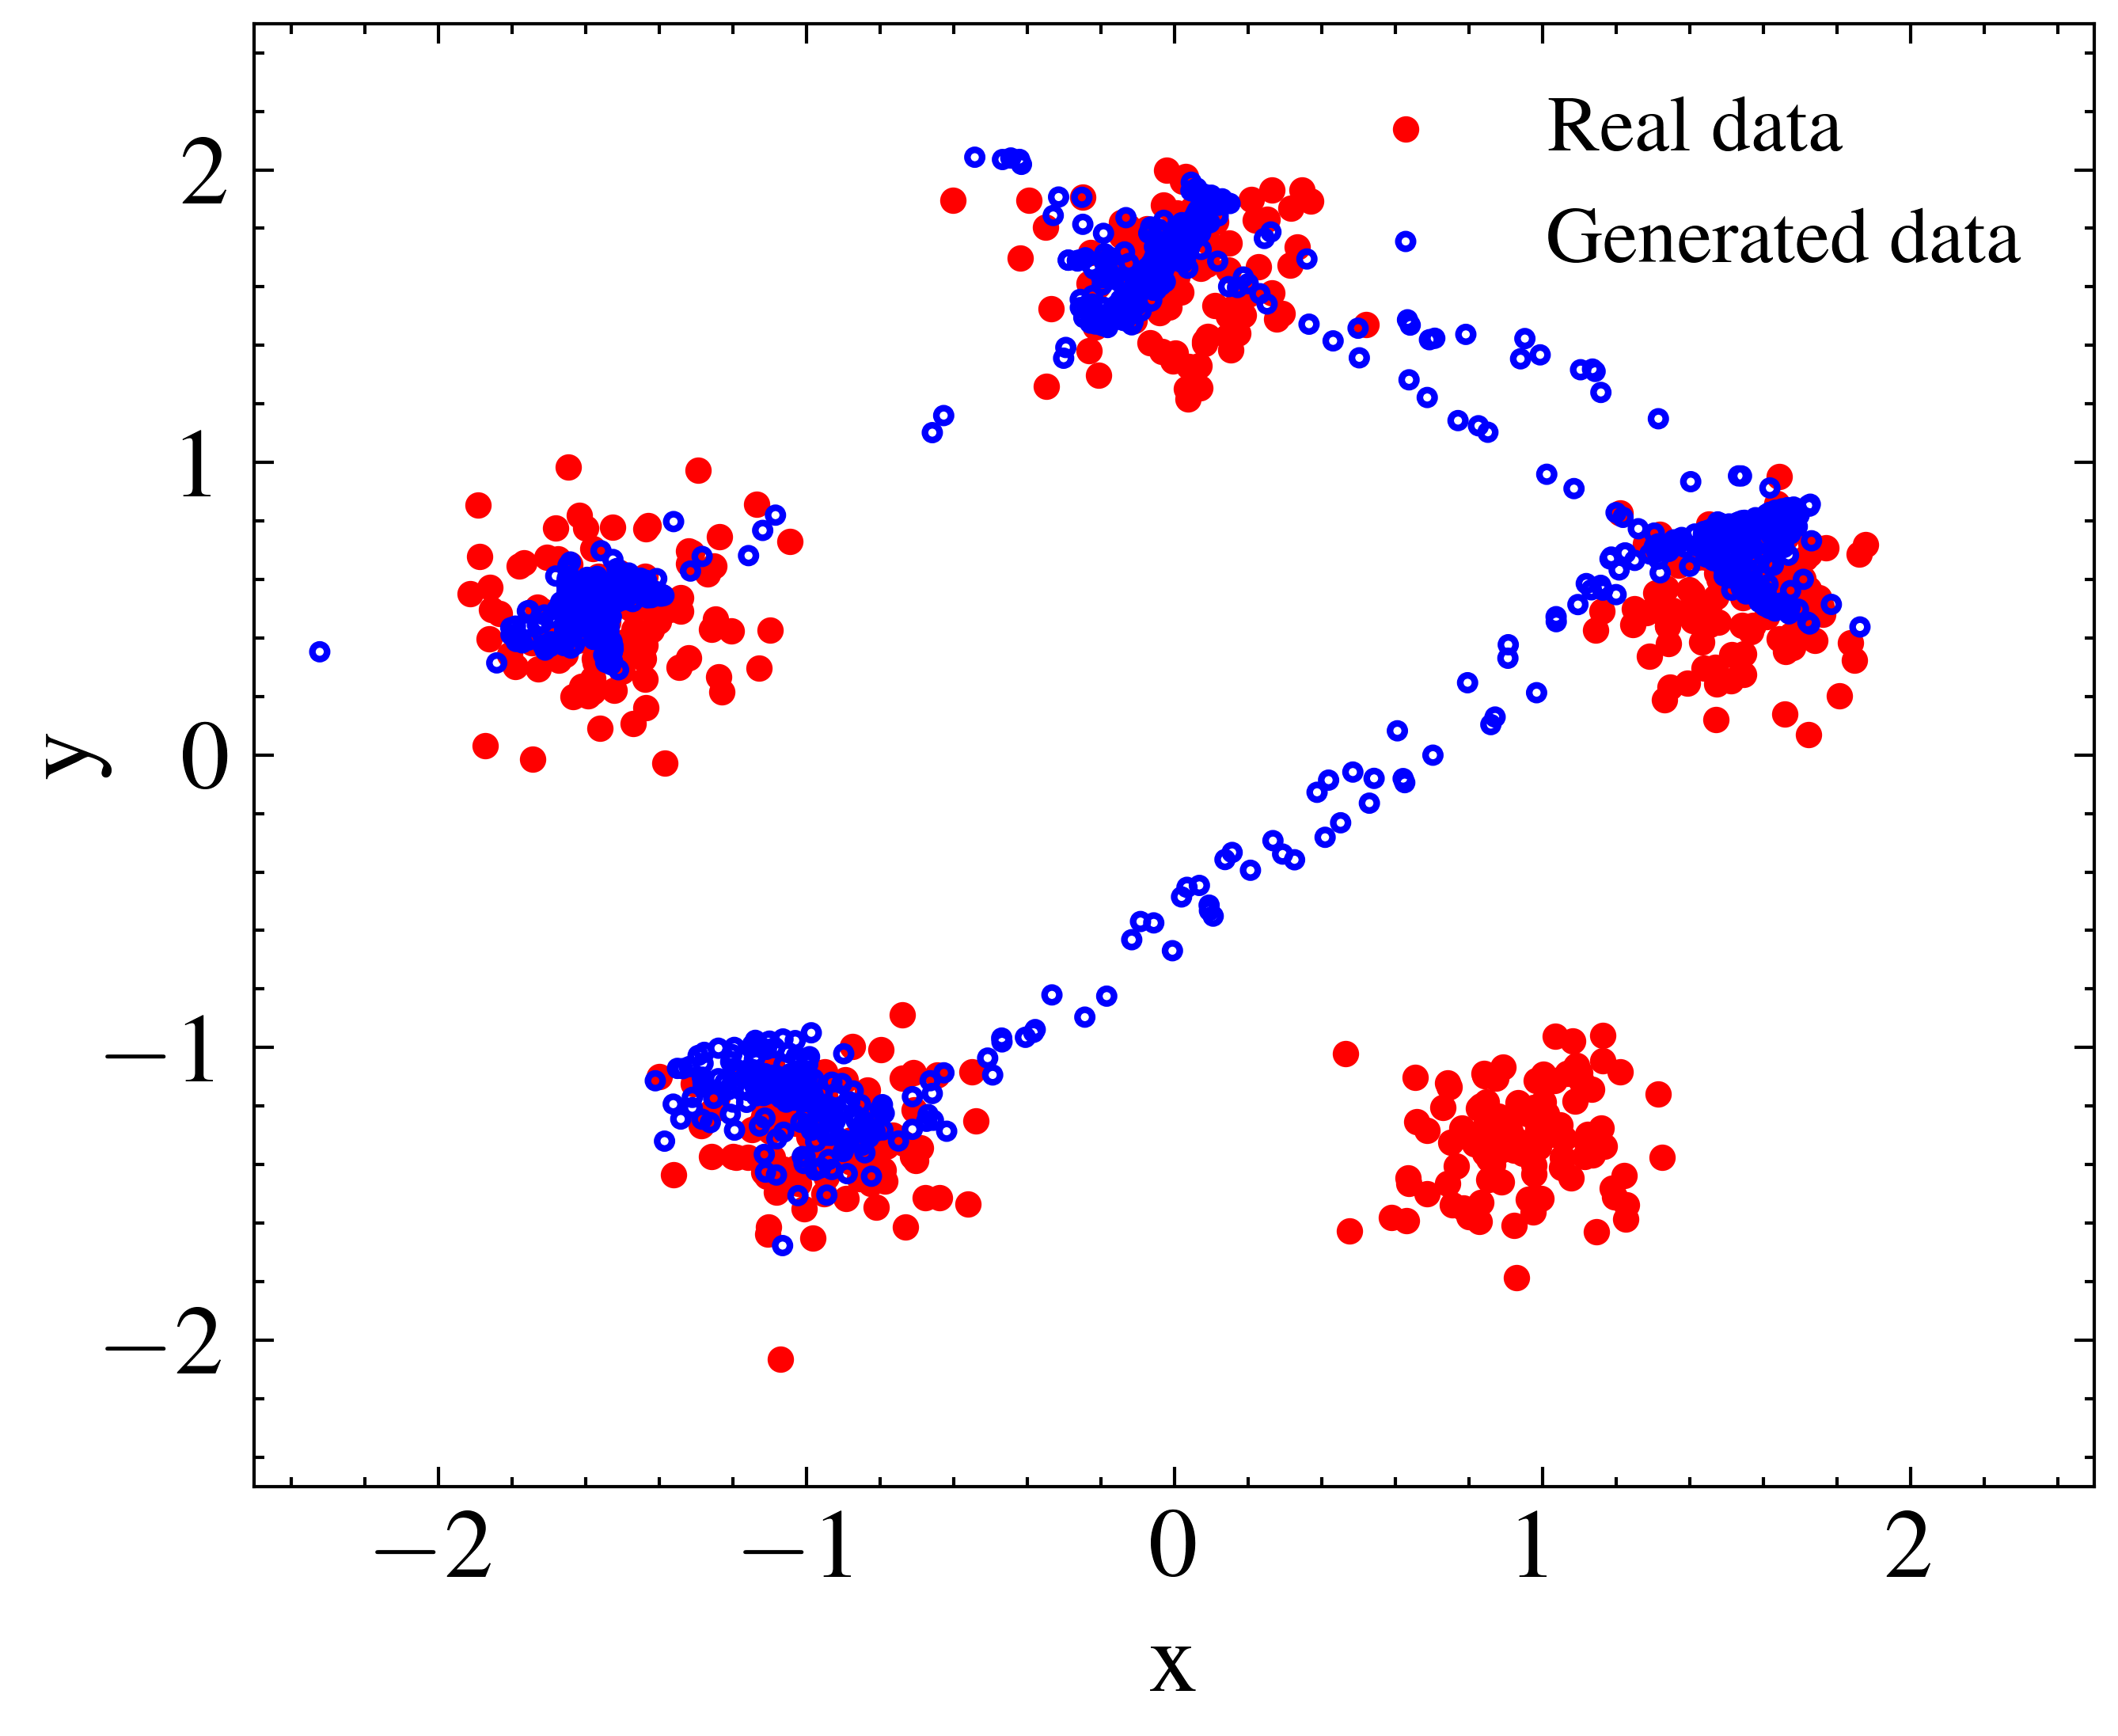


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.6140
Precision（生成样本落入真实密度区域比例）: 0.9150


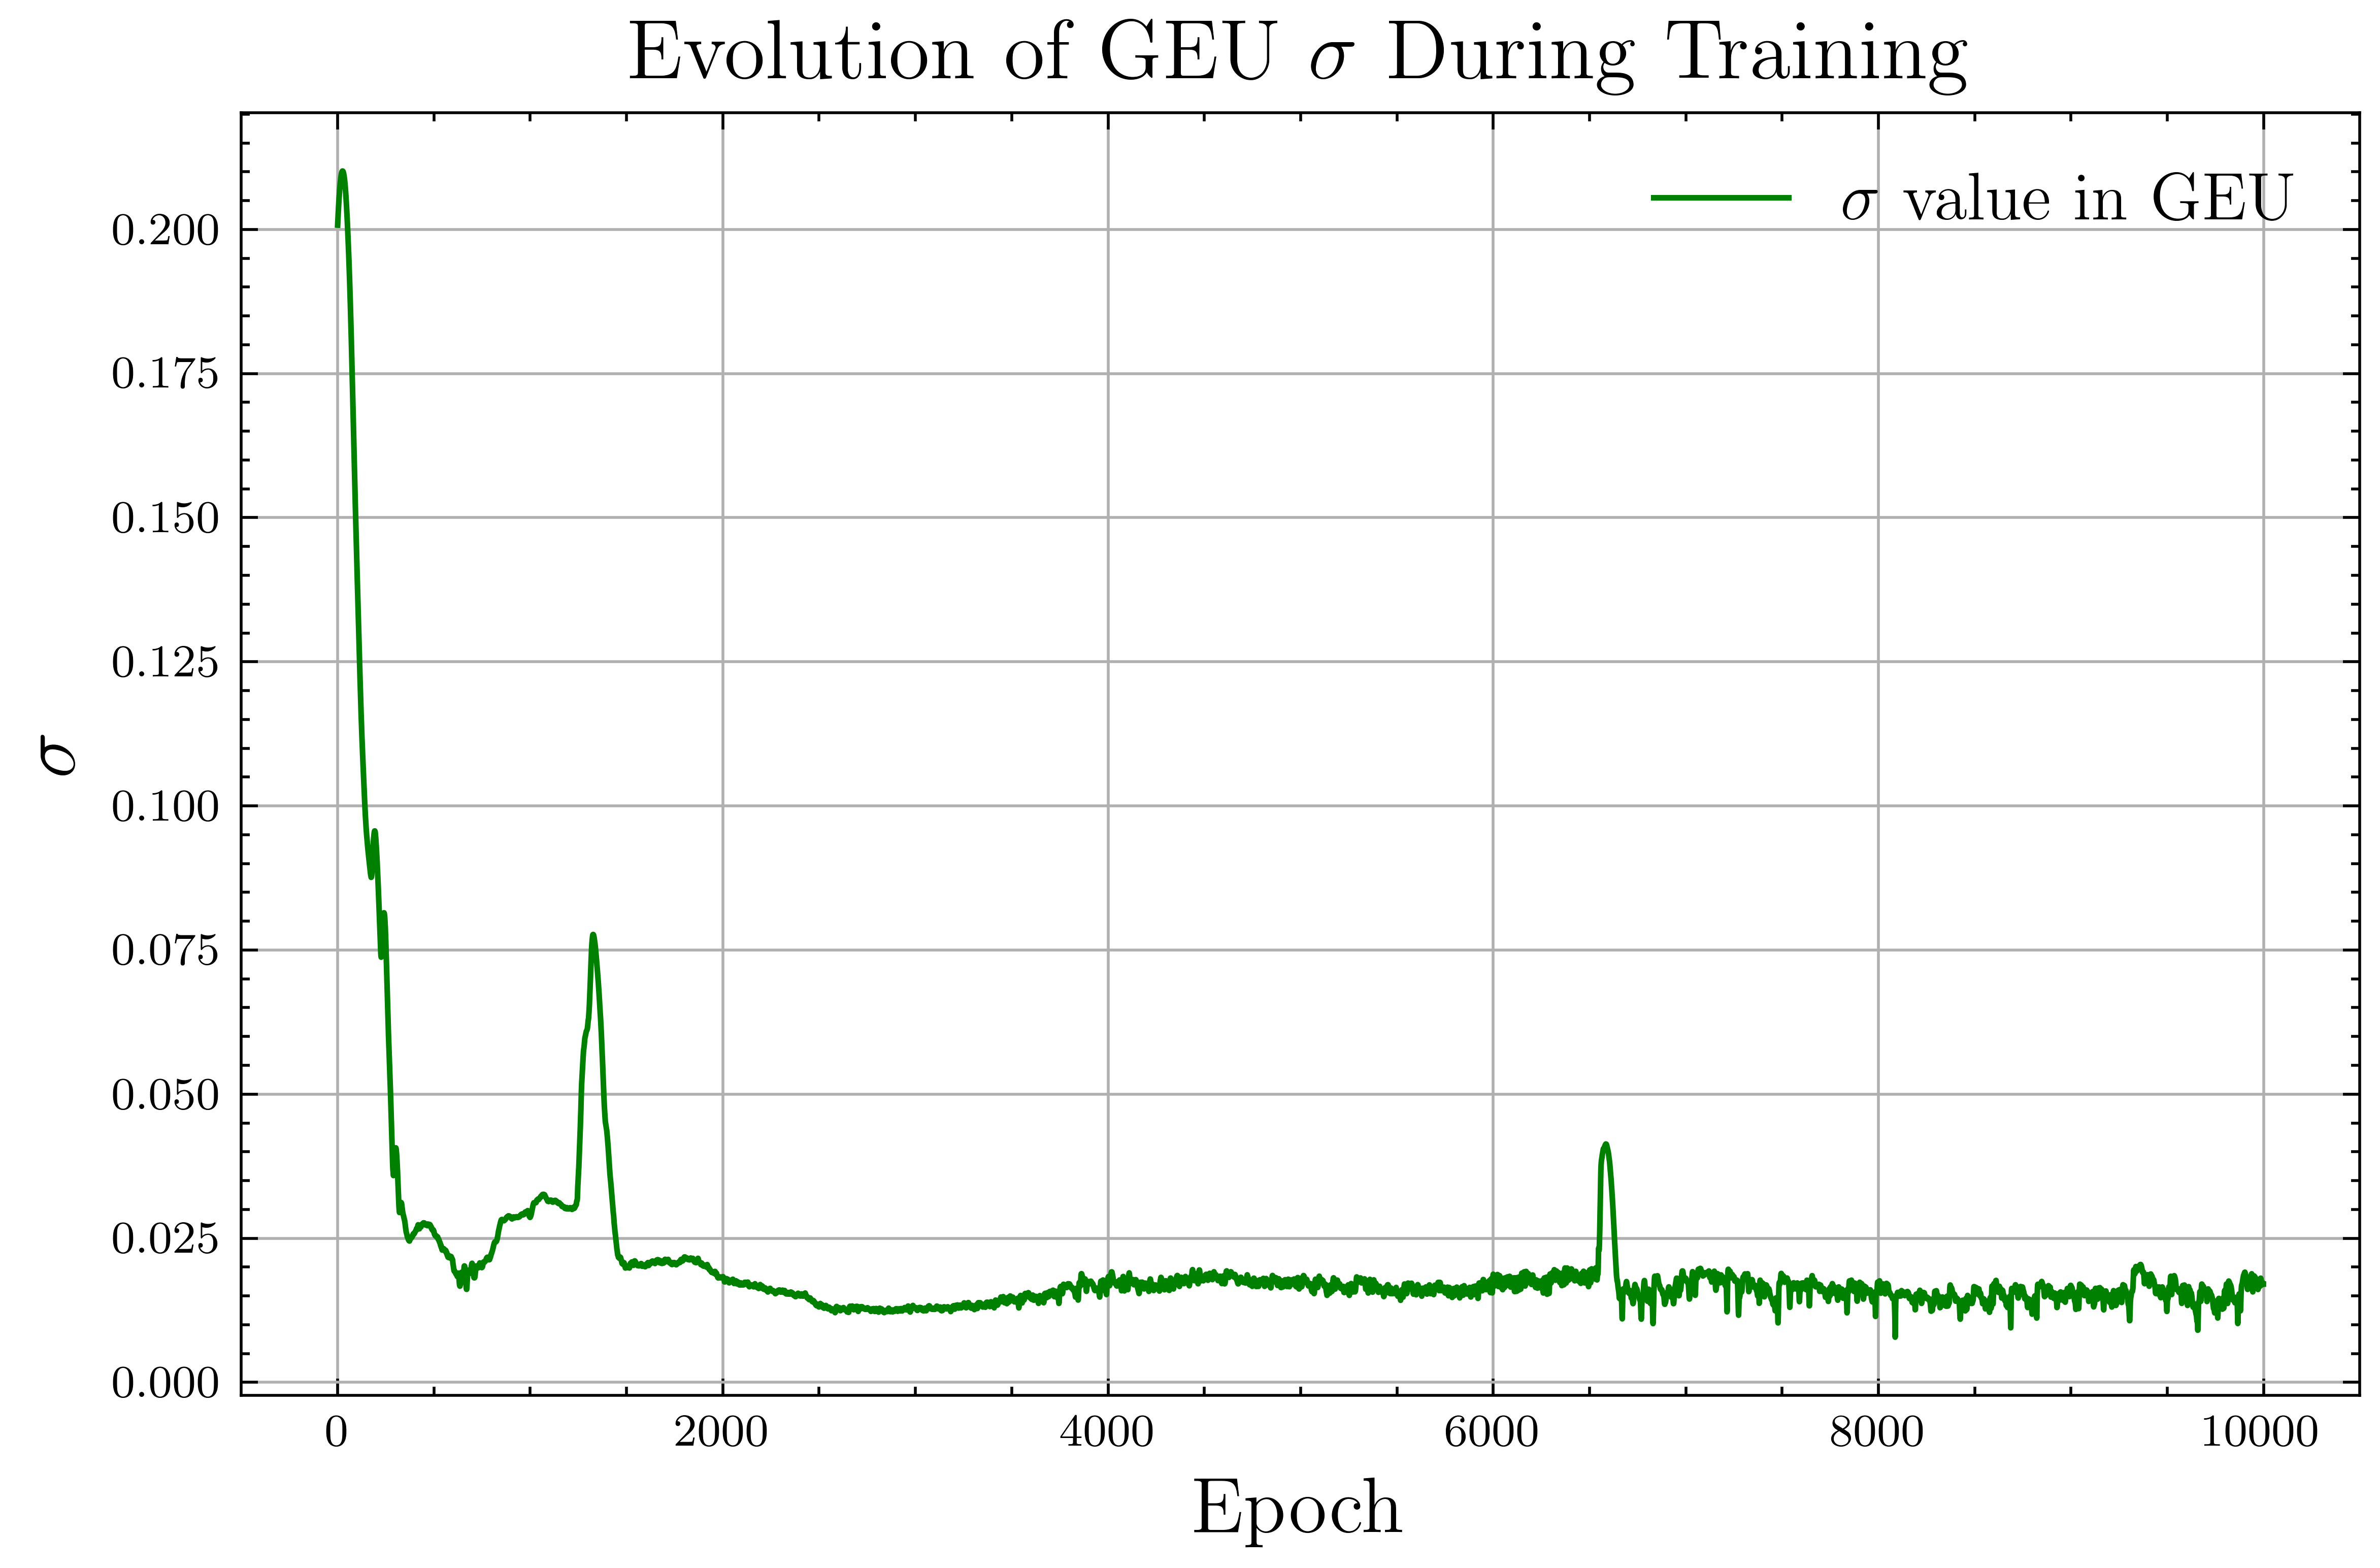

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class GEU(nn.Module):
    def __init__(self, init_sigma=0.20):  # 建议默认值就写 1.0（浮点数）
        super(GEU, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = (1 + torch.erf(input / (torch.sqrt(torch.tensor(2.0)) * sigma_safe))) / 2
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.GEU = GEU()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.GEU(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.GEU.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载 sigma 数据
#epoch_sigma_values = np.load("D:/PRE2023 2025/epoch_sigma_values742.npy")

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(epoch_sigma_values, label=r'$\sigma$ value in GEU', color='green')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.title('Evolution of GEU $\sigma$ During Training', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("D:/PRE2023 2025/sigma742.pdf")  # 可选保存为 PDF
plt.show()

In [ ]:
np.save("D:/PRE2023 2025/epoch_sigma_valuesGEU742-2026.npy", epoch_sigma_values)

Epoch 0: D Loss: 1.5563, G Loss: -0.4029, G Grad Norm^2: 0.007081
Epoch 100: D Loss: 0.9756, G Loss: -0.4668, G Grad Norm^2: 0.048797
Epoch 200: D Loss: 0.9094, G Loss: -0.2577, G Grad Norm^2: 0.593358
Epoch 300: D Loss: 1.0120, G Loss: -0.3795, G Grad Norm^2: 7.705374
Epoch 400: D Loss: 0.3237, G Loss: -0.1593, G Grad Norm^2: 17.378557
Epoch 500: D Loss: 0.5513, G Loss: -0.1982, G Grad Norm^2: 3.910525
Epoch 600: D Loss: 0.8567, G Loss: -0.4113, G Grad Norm^2: 2.937801
Epoch 700: D Loss: 0.6992, G Loss: -0.3313, G Grad Norm^2: 0.715512
Epoch 800: D Loss: 0.6965, G Loss: -0.3259, G Grad Norm^2: 1.031860
Epoch 900: D Loss: 0.6652, G Loss: -0.3076, G Grad Norm^2: 2.473552
Epoch 1000: D Loss: 0.7571, G Loss: -0.3889, G Grad Norm^2: 13.939979
Epoch 1100: D Loss: 0.6779, G Loss: -0.3274, G Grad Norm^2: 1.072361
Epoch 1200: D Loss: 0.6969, G Loss: -0.3335, G Grad Norm^2: 2.721712
Epoch 1300: D Loss: 0.6972, G Loss: -0.3342, G Grad Norm^2: 4.462542
Epoch 1400: D Loss: 0.7359, G Loss: -0.3458,

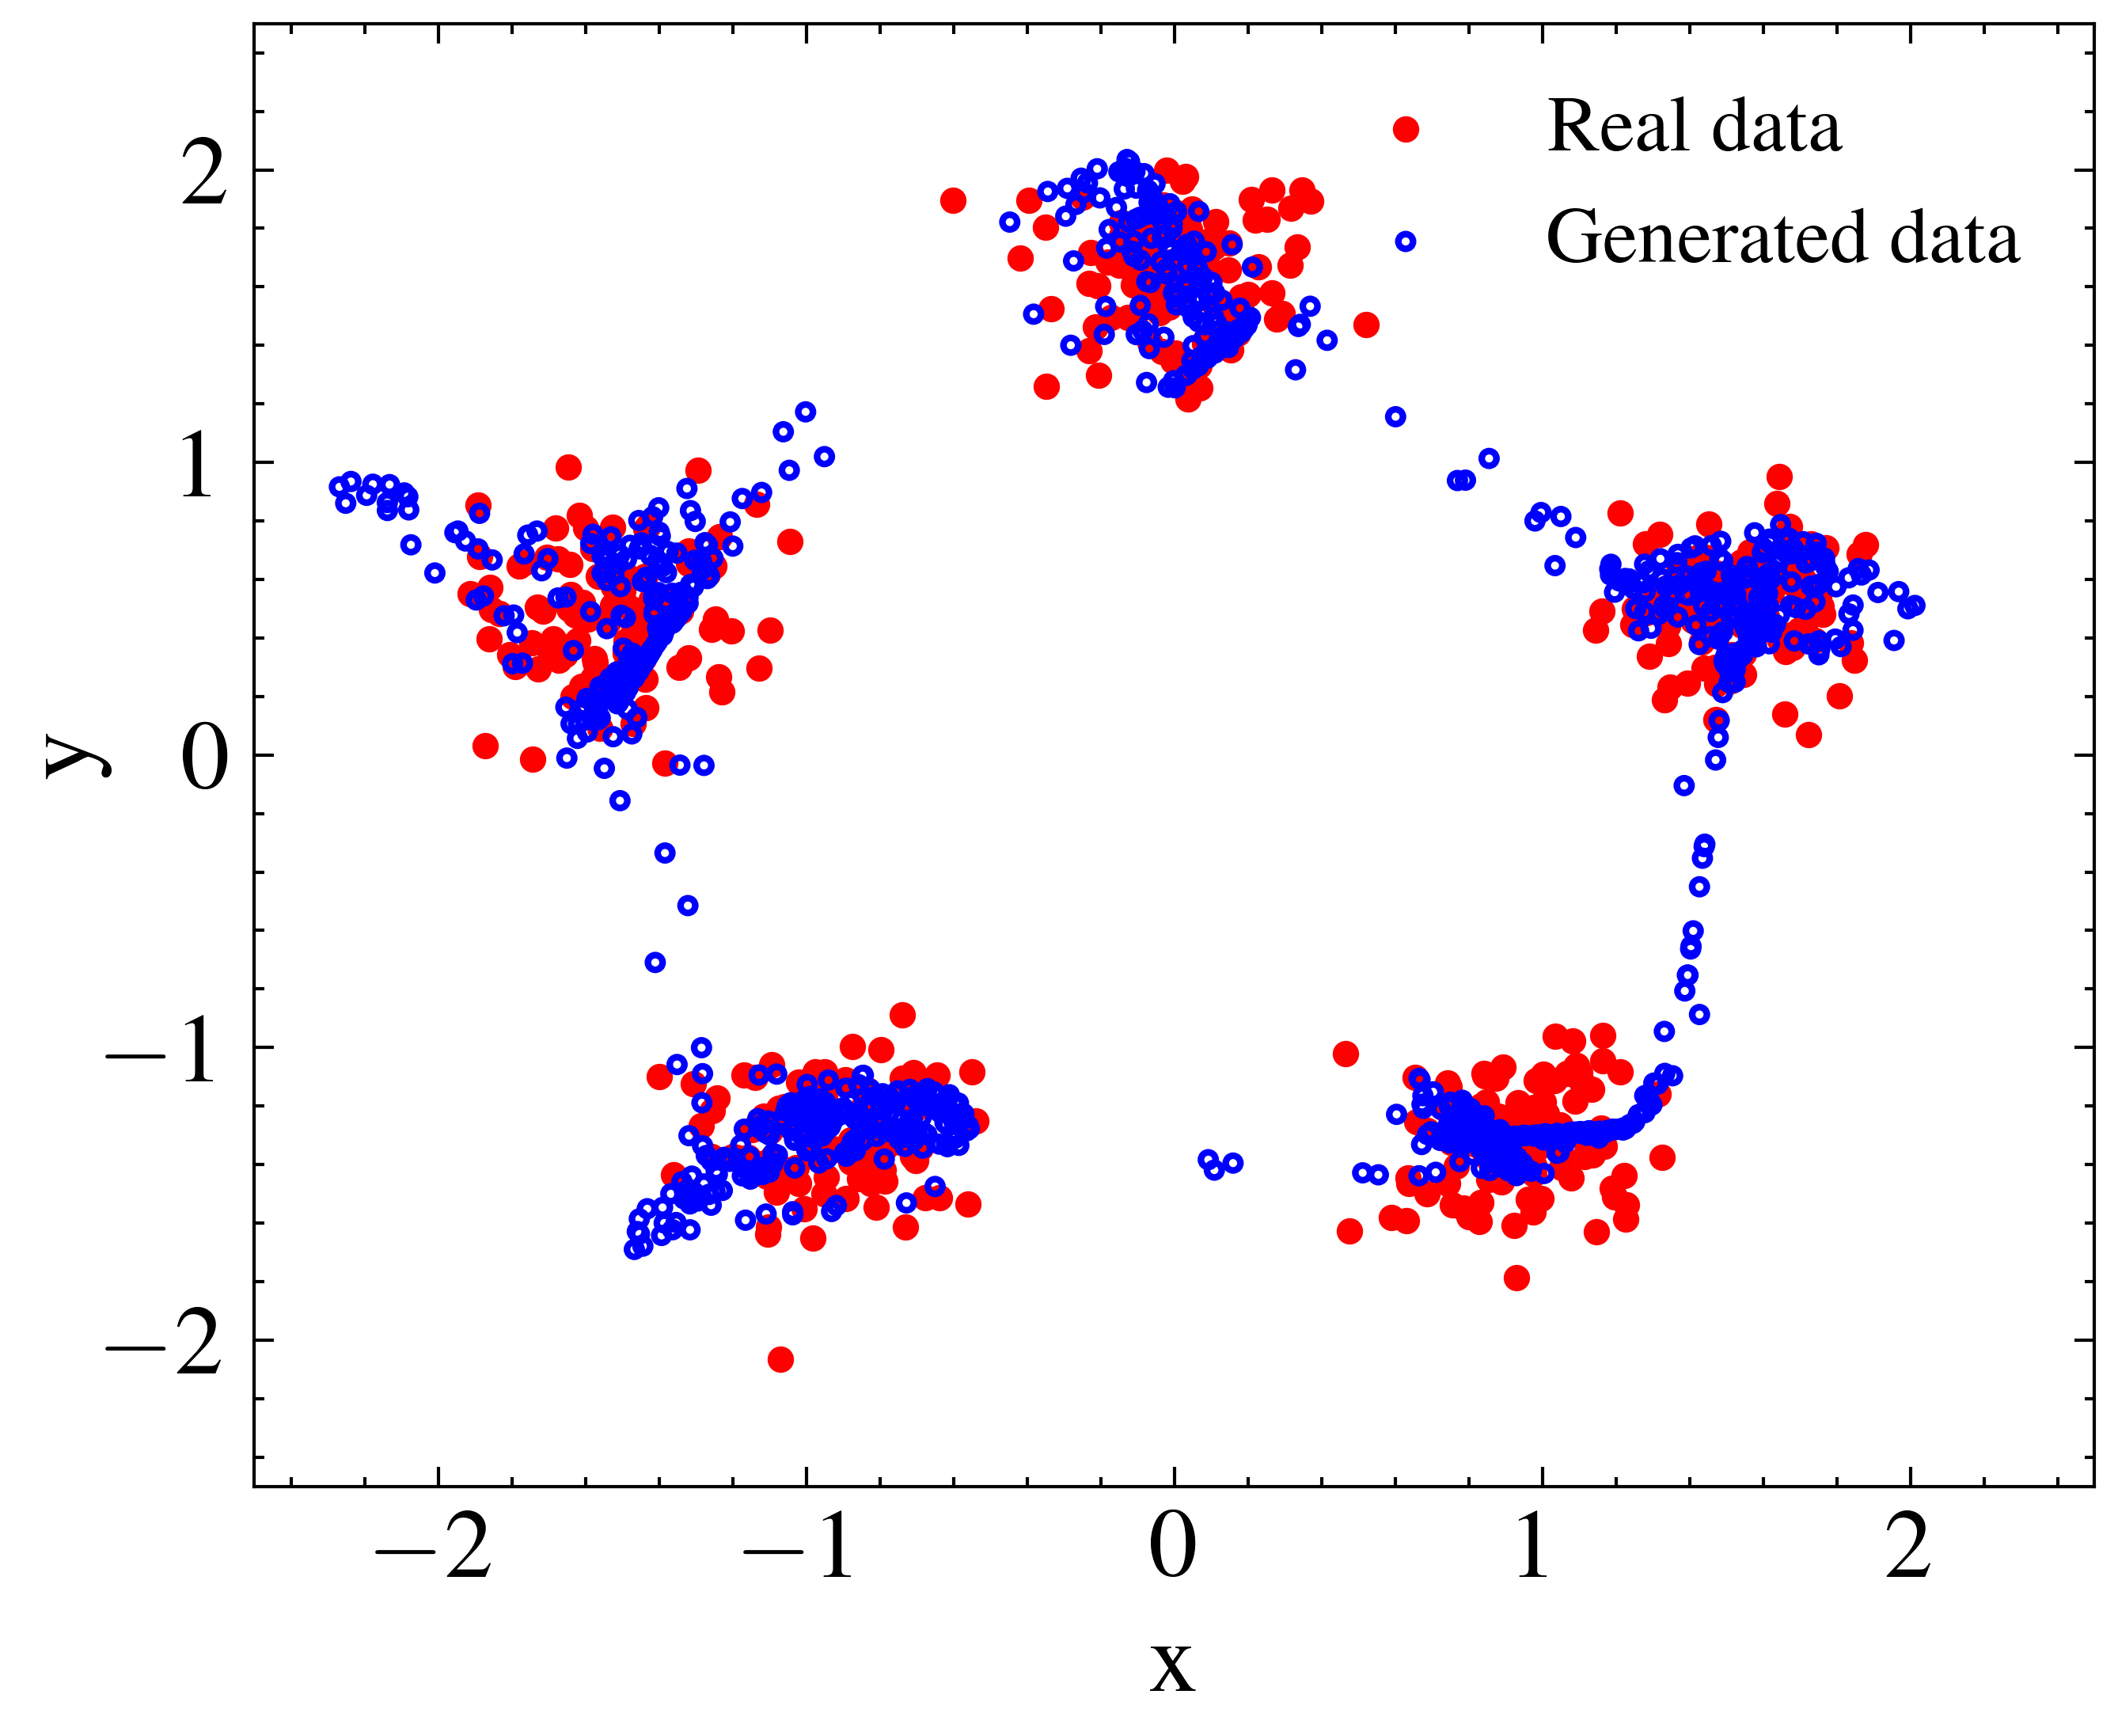


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.8440
Precision（生成样本落入真实密度区域比例）: 0.9060


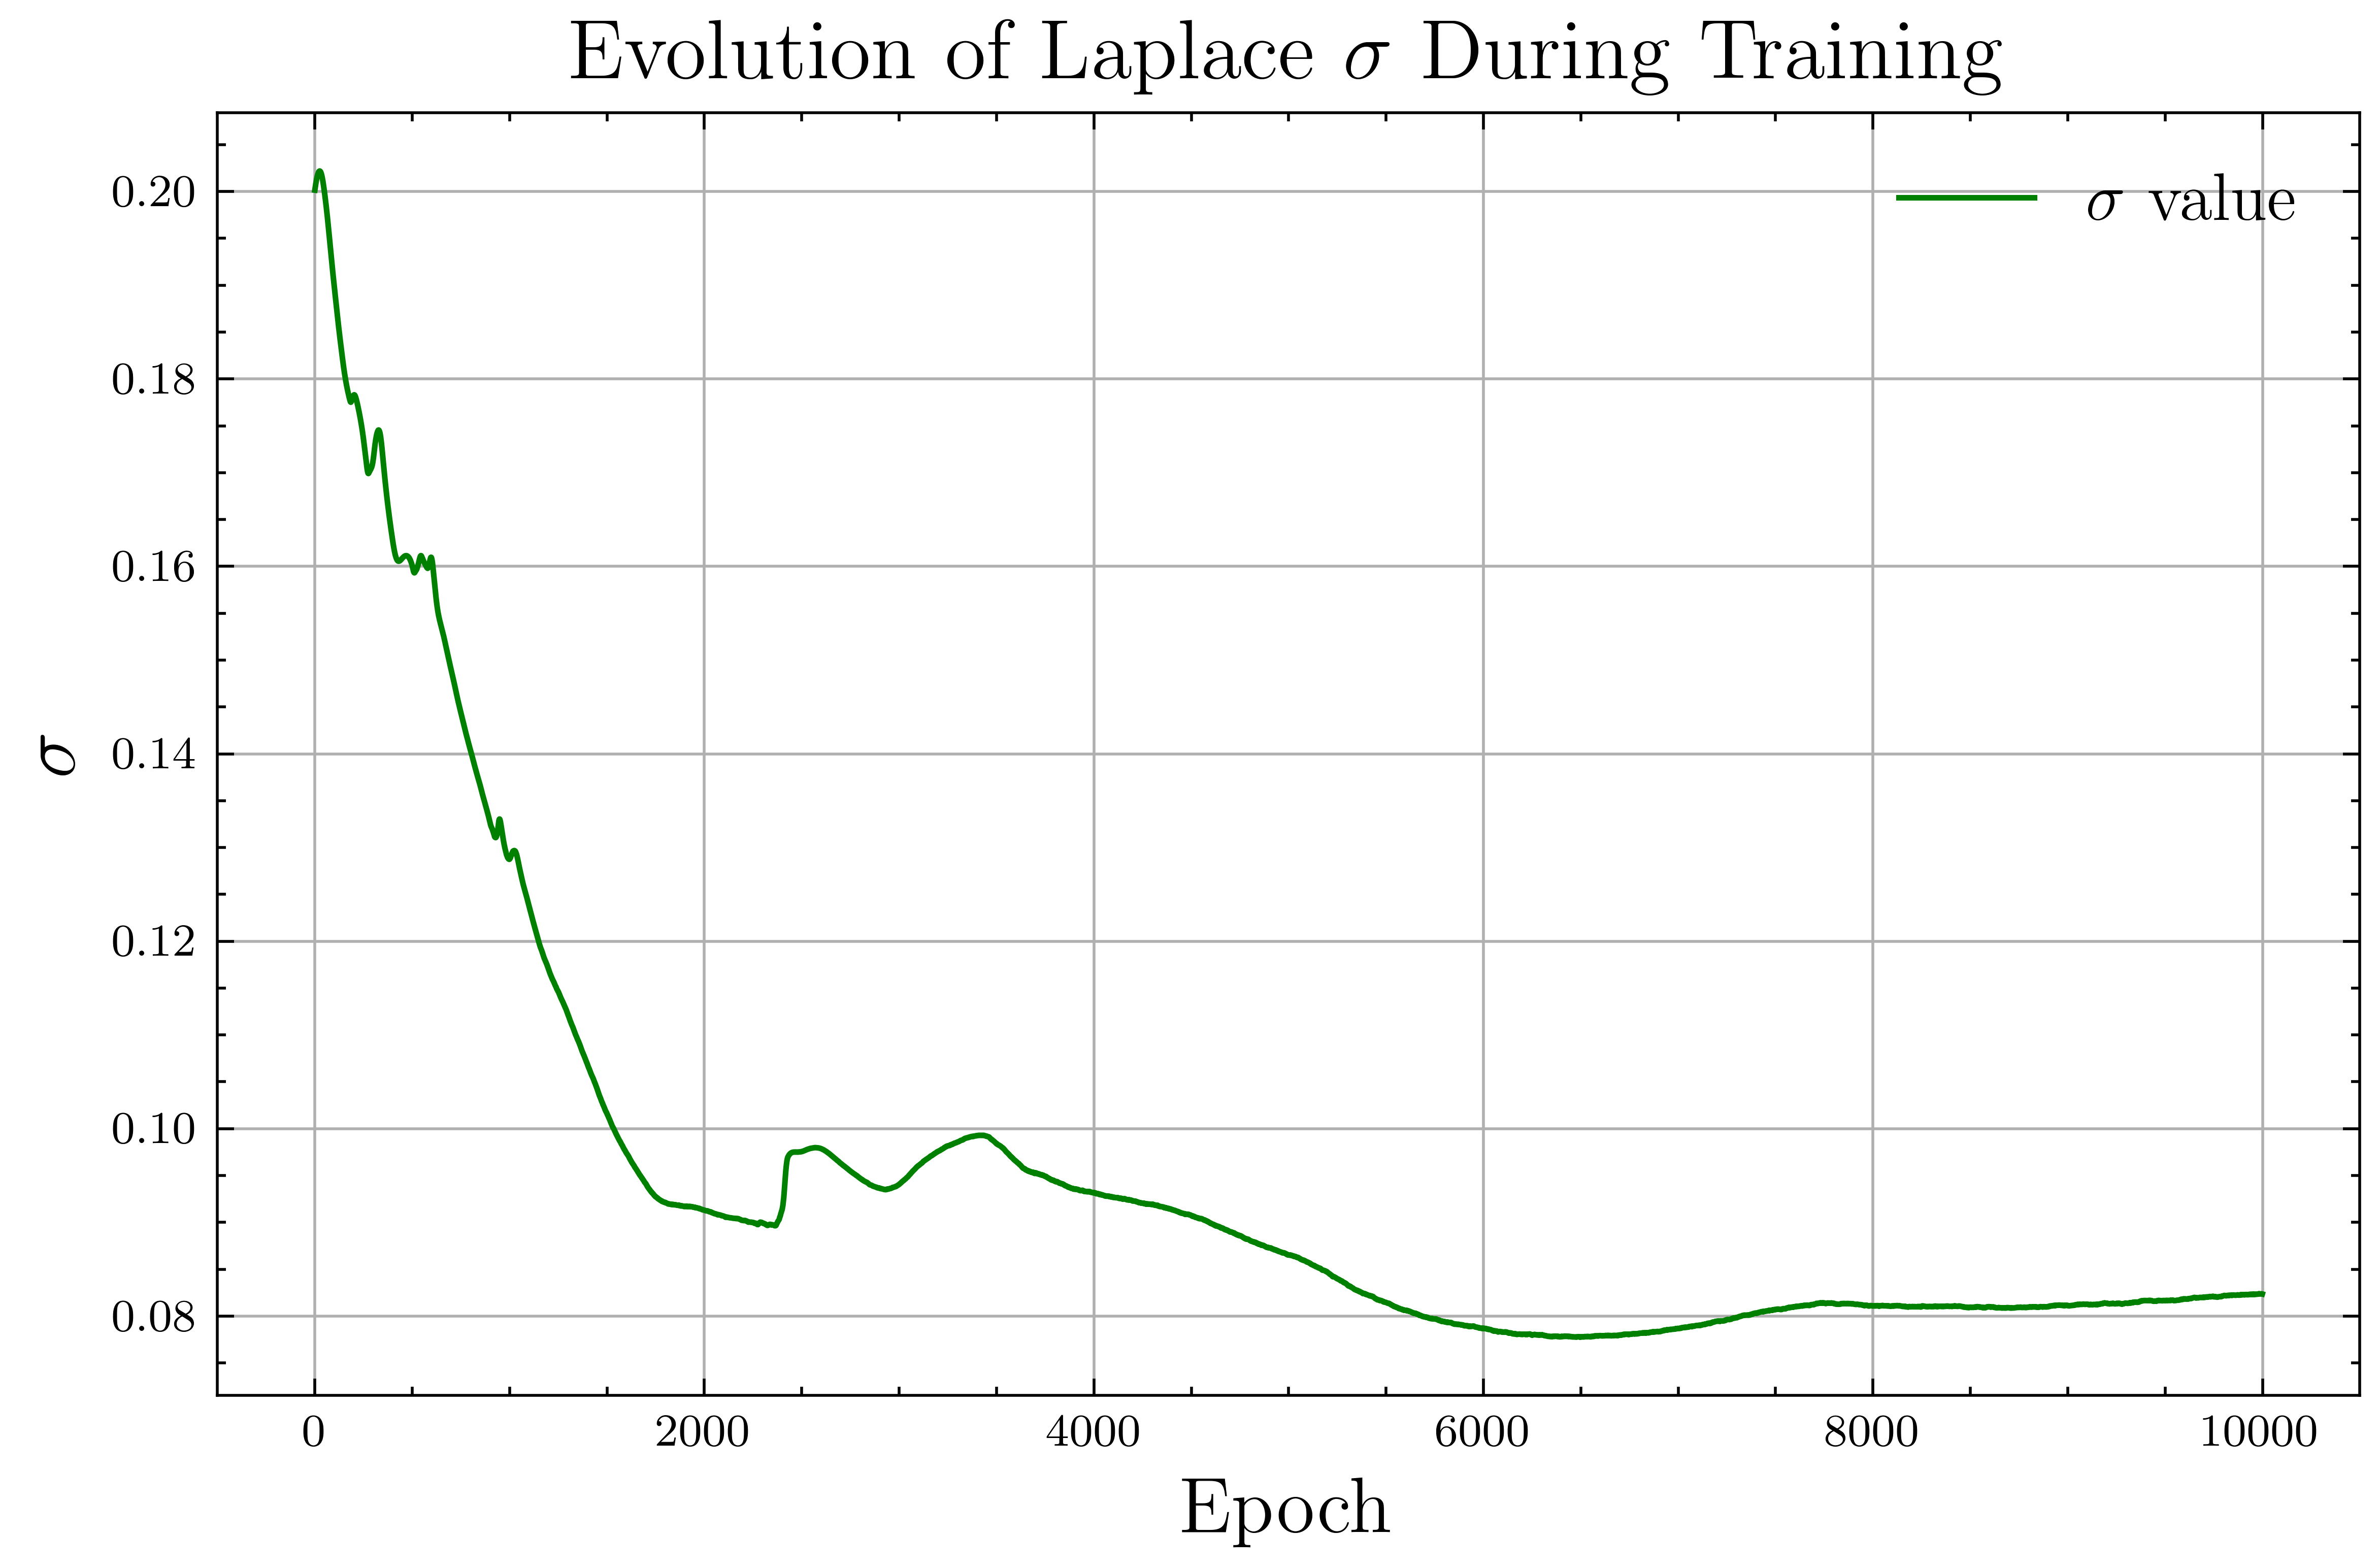

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class LaplaceCDF(nn.Module):
    def __init__(self, init_sigma=0.2):
        super(LaplaceCDF, self).__init__()
        self.log_sigma = nn.Parameter(
            torch.tensor(np.log(init_sigma), dtype=torch.float32)
        )

    @property
    def sigma(self):
        return torch.exp(self.log_sigma)

    def forward(self, input):
        sigma = self.sigma
        output = torch.where(
            input < 0,
            0.5 * torch.exp(input / sigma),
            1 - 0.5 * torch.exp(-input / sigma)
        )
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.LaplaceCDF = LaplaceCDF()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.LaplaceCDF(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.LaplaceCDF.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载 sigma 数据
#epoch_sigma_values = np.load("D:/PRE2023 2025/epoch_sigma_values742.npy")

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(epoch_sigma_values, label=r'$\sigma$ value', color='green')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.title('Evolution of Laplace $\sigma$ During Training', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("D:/PRE2023 2025/sigma742.pdf")  # 可选保存为 PDF
plt.show()

In [7]:
np.save("D:/PRE2023 2025/epoch_sigma_valuesLap742-2026.npy", epoch_sigma_values)

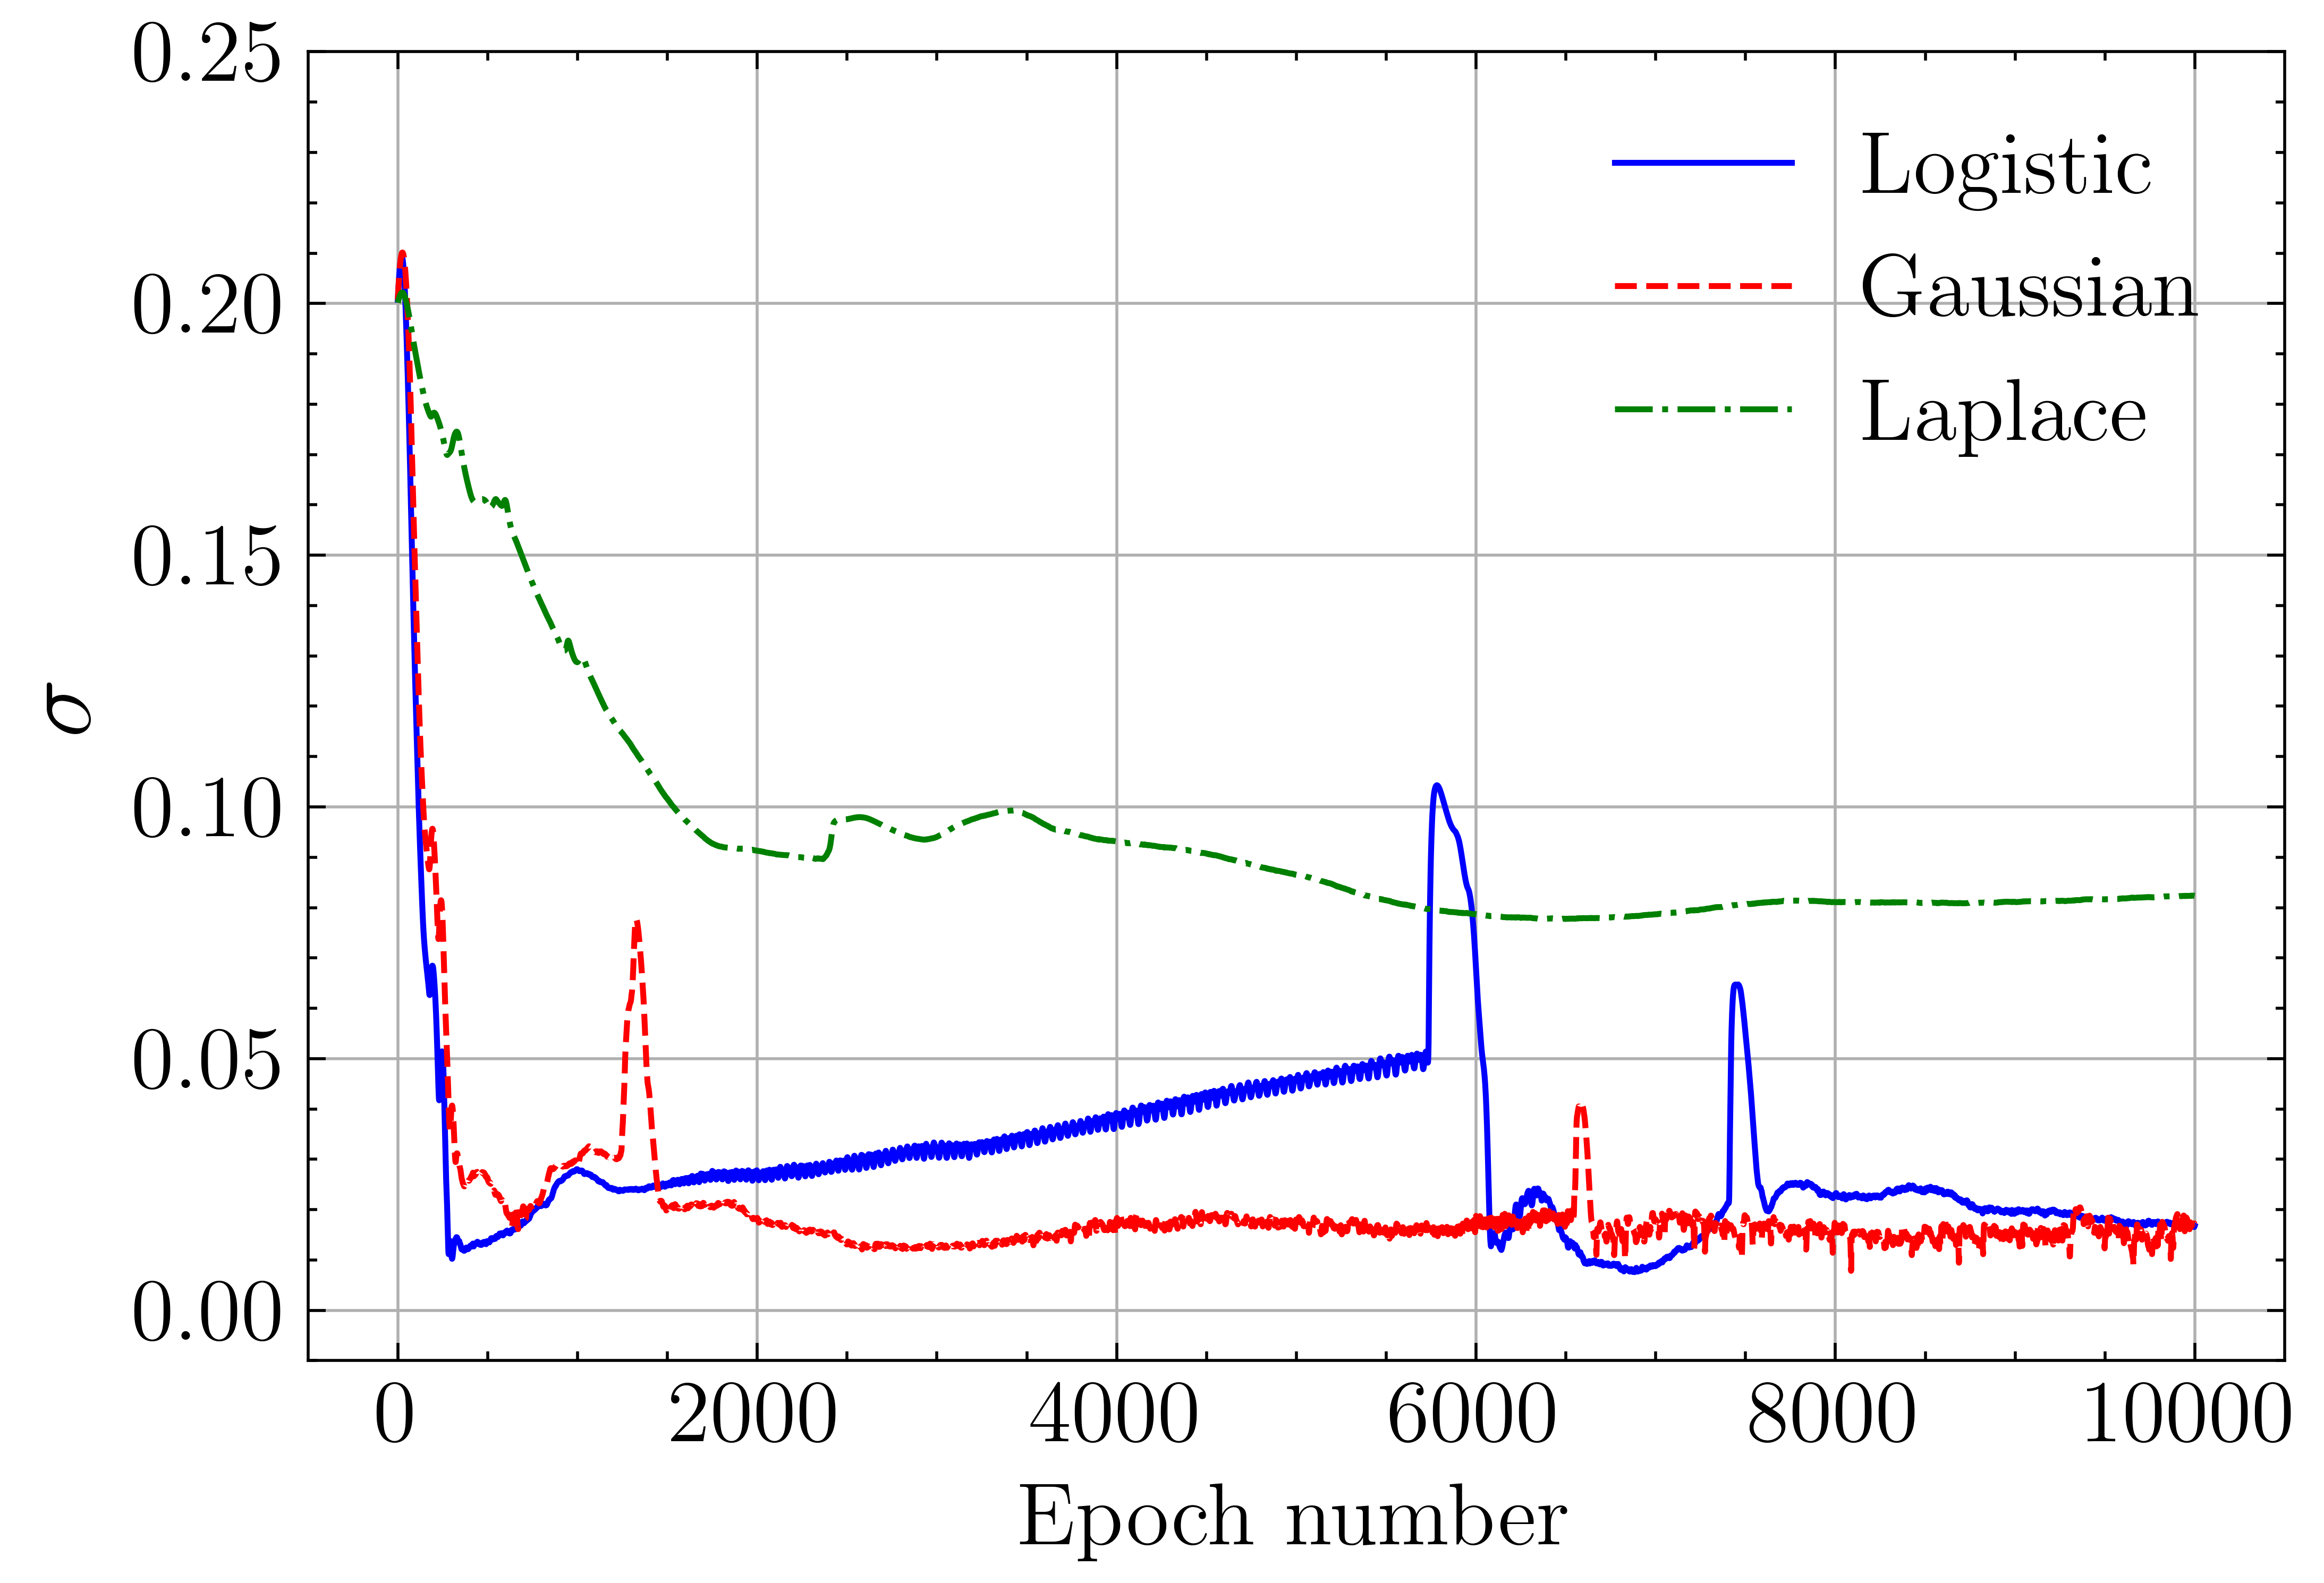

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

# 设置样式
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

# 载入两组 sigma 数据
sigma_sig = np.load("D:/PRE2023 2025/epoch_sigma_valuessig742.npy")
sigma_geu = np.load("D:/PRE2023 2025/epoch_sigma_valuesGEU742-2026.npy")
sigma_lap = np.load("D:/PRE2023 2025/epoch_sigma_valuesLap742-2026.npy")

# 绘图
plt.figure(figsize=(6, 4))
ax = plt.gca()  # 获取当前轴对象

ax.plot(sigma_sig, label='Logistic', color='blue', linestyle='-')
ax.plot(sigma_geu, label='Gaussian', color='red', linestyle='--')
ax.plot(sigma_lap, label='Laplace', color='green', linestyle='-.')
ax.set_xlabel('Epoch number', fontsize=15)
ax.set_ylabel(r'$\sigma$', fontsize=17)
ax.tick_params(labelsize=15)  # 设置坐标轴刻度字体大小
ax.set_ylim(-0.01, 0.25)
ax.set_ylim(-0.01, 0.25)
ax.grid(True)
ax.legend(fontsize=15)
plt.savefig("D:/PRE2023 2025/Fig4.eps", dpi=800)
plt.show()